# EDA — Women's E-Commerce Clothing Reviews

Schema check, rating distribution / class imbalance, review length, missing text, and department/class breakdown.

Loader: `src/data/load.py` (schema-validated, unit-tested in `tests/data/test_load.py`).

In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data.load import load_reviews, schema_report

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

df = load_reviews()
df.shape

(23486, 10)

## 1. Schema, nulls, duplicates

In [2]:
report = schema_report(df)
print(f"rows: {report.attrs['n_rows']}   duplicate rows: {report.attrs['n_duplicate_rows']}")
report

rows: 23486   duplicate rows: 21


,dtype,n_nulls,null_rate
Clothing ID,int64,0,0.0000
Age,int64,0,0.0000
Title,str,3810,0.1622
Review Text,str,845,0.0360
Rating,int64,0,0.0000
Recommended IND,int64,0,0.0000
Positive Feedback Count,int64,0,0.0000
Division Name,str,14,0.0006
Department Name,str,14,0.0006
Class Name,str,14,0.0006


`Title` and `Review Text` carry most of the missingness. `Division/Department/Class Name` are missing together on the same ~14 rows (likely a discontinued Clothing ID).

In [3]:
df[df["Division Name"].isna()]

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
9444,72,25,My favorite socks!!!,"I never write reviews, but these socks are so worth it! they are incredibly soft, stretchy, and hug your feet just t...",5,1,0,NaN,NaN,NaN
13767,492,23,So soft!,I just love this hoodie! it is so soft and comfortable. i am usually an extra small and that size fit me great. i wi...,5,1,1,NaN,NaN,NaN
13768,492,49,Wardrobe staple,Love this hoodie. so soft and goes with everything. highly recommend for comfort and style. great company.,5,1,0,NaN,NaN,NaN
13787,492,48,NaN,NaN,5,1,0,NaN,NaN,NaN
16216,152,36,Warm and cozy,"Just what i was looking for. soft, cozy and warm.",5,1,0,NaN,NaN,NaN
16221,152,37,Love!,I am loving these. they are quite long but are prefect to wear with pj shorts or leggings. very soft and cozy.,5,1,0,NaN,NaN,NaN
16223,152,39,"""long and warm""",These leg warmers are perfect for me. they are long enough and thick and warm enough to keep me from freezing in col...,5,1,0,NaN,NaN,NaN
18626,184,34,Nubby footless tights,"These are amazing quality. i agree, size up to not have such a sheer effect. i would not wear them as just leggings ...",5,1,5,NaN,NaN,NaN
18671,184,54,New workhorse,"These tights are amazing! if i care for them well, i know they will last me seasons upon seasons.",5,1,0,NaN,NaN,NaN
20088,772,50,Comfy sweatshirt!,"This sweatshirt is really nice! it's oversized so best worn with leggings or skinny jeans. it's very warm, without ...",5,1,0,NaN,NaN,NaN


## 2. Rating distribution & class imbalance

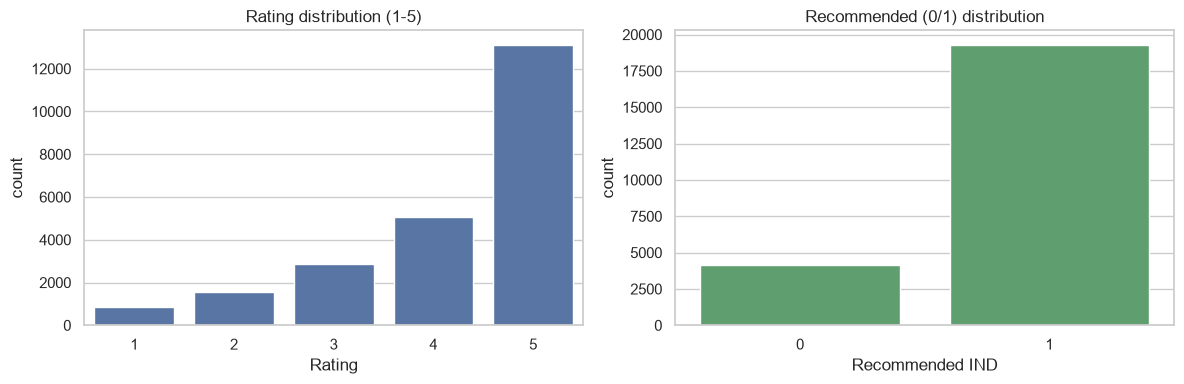

Rating
1    0.036
2    0.067
3    0.122
4    0.216
5    0.559
Name: proportion, dtype: float64

Recommended IND
1    0.822
0    0.178
Name: proportion, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x="Rating", data=df, ax=axes[0], color="#4C72B0")
axes[0].set_title("Rating distribution (1-5)")

sns.countplot(x="Recommended IND", data=df, ax=axes[1], color="#55A868")
axes[1].set_title("Recommended (0/1) distribution")

plt.tight_layout()
plt.show()

print(df["Rating"].value_counts(normalize=True).sort_index().round(3))
print()
print(df["Recommended IND"].value_counts(normalize=True).round(3))

Both targets are heavily skewed toward positive (Rating 4-5, Recommended=1) — confirms the class-imbalance handling task on the roadmap (class weights and/or SMOTE) is needed for both the sentiment/rating classifier and the recommendation classifier.

## 3. Review length

In [5]:
df["review_word_count"] = df["Review Text"].fillna("").str.split().str.len()
df["has_review_text"] = df["Review Text"].notna()

df["review_word_count"].describe()

count    23486.000000
mean        58.030869
std         30.176433
min          0.000000
25%         34.000000
50%         57.000000
75%         87.000000
max        115.000000
Name: review_word_count, dtype: float64

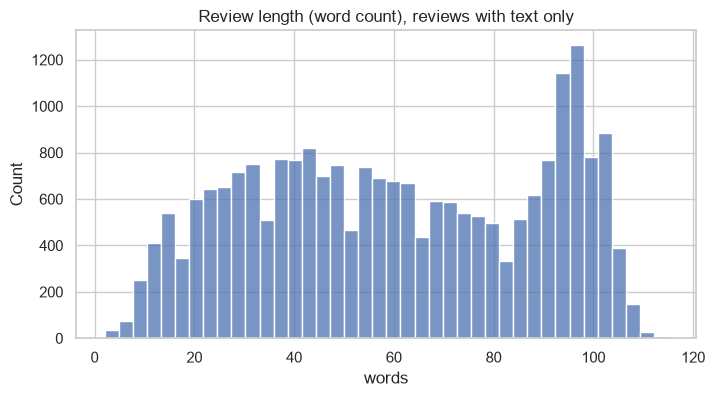

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df.loc[df["has_review_text"], "review_word_count"], bins=40, ax=ax)
ax.set_title("Review length (word count), reviews with text only")
ax.set_xlabel("words")
plt.show()

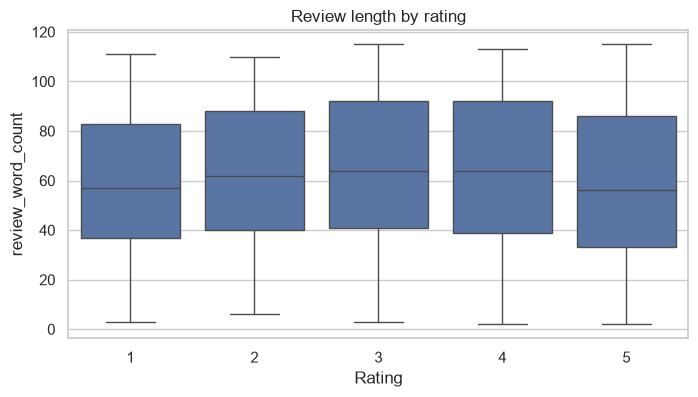

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x="Rating", y="review_word_count", data=df[df["has_review_text"]], ax=ax, color="#4C72B0")
ax.set_title("Review length by rating")
plt.show()

## 4. Missing review text

Rows with no `Review Text` can't feed the text classifiers or topic models — check whether they skew toward particular ratings/departments before deciding to drop them.

missing Review Text: 845 / 23486 (3.60%)


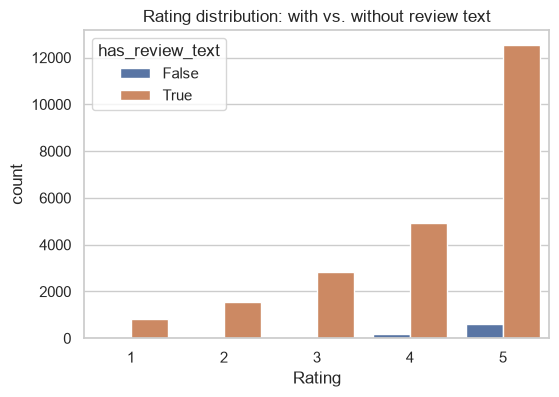

In [8]:
print(f"missing Review Text: {df['Review Text'].isna().sum()} / {len(df)} "
      f"({df['Review Text'].isna().mean():.2%})")

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x="Rating", hue="has_review_text", data=df, ax=ax)
ax.set_title("Rating distribution: with vs. without review text")
plt.show()

## 5. Department / class breakdown

Department Name
Tops        10468
Dresses      6319
Bottoms      3799
Intimate     1735
Jackets      1032
Trend         119
Name: count, dtype: int64


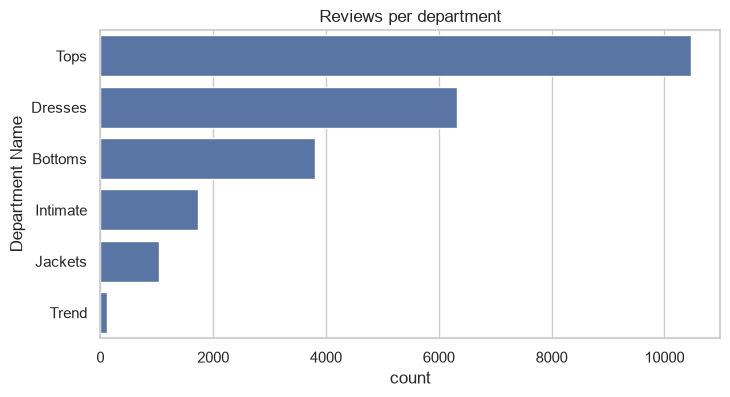

In [9]:
dept_counts = df["Department Name"].value_counts()
print(dept_counts)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=dept_counts.values, y=dept_counts.index, ax=ax, color="#4C72B0")
ax.set_title("Reviews per department")
ax.set_xlabel("count")
plt.show()

20 distinct classes


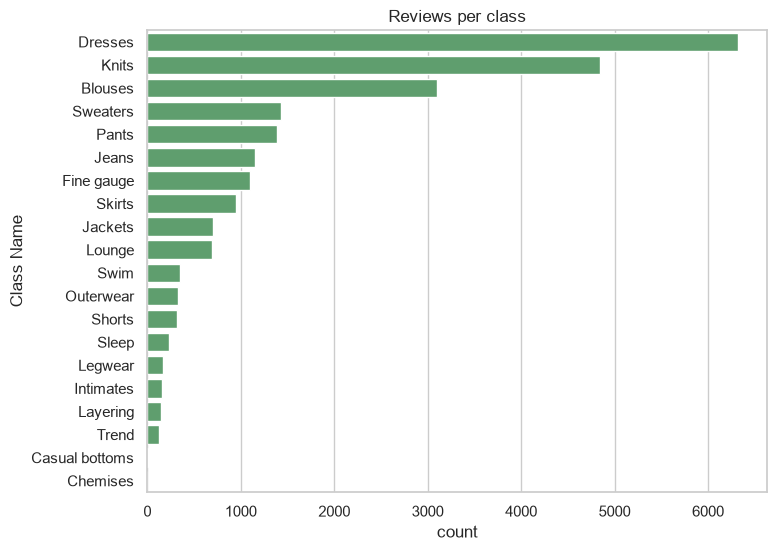

In [10]:
class_counts = df["Class Name"].value_counts()
print(f"{class_counts.shape[0]} distinct classes")

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=class_counts.values, y=class_counts.index, ax=ax, color="#55A868")
ax.set_title("Reviews per class")
ax.set_xlabel("count")
plt.show()

In [11]:
# Mean rating by department — sanity check for department-level sentiment skew
df.groupby("Department Name")["Rating"].agg(["mean", "count"]).sort_values("mean")

,mean,count
Department Name,,
Trend,3.815126,119
Dresses,4.150815,6319
Tops,4.172239,10468
Jackets,4.264535,1032
Intimate,4.280115,1735
Bottoms,4.288760,3799


## Summary / decisions for next steps

- **Class imbalance** confirmed for both Rating and Recommended IND — plan class weights and/or SMOTE at model-training time.
- **~3.6% of rows have no `Review Text`** — these can't be used for the text classifiers or topic models; drop them for those tasks but keep for any rating-only analysis.
- **14 rows missing Division/Department/Class** — small enough to drop.
- **21 duplicate rows** — drop before splitting to avoid train/test leakage.
- **`Trend` department has by far the fewest reviews** — worth flagging as low-support in per-department breakdowns.
- Open item carried to `project-architecture.md`: whether to keep `Age`/`Division Name` as model features, pending further EDA.